✅ Fichier chargé avec succès.
Dimensions initiales : (81, 8)
  nom opérateur  ligne  Code produit     Produit à ré-étiqueter  N° de lot   \
0         FADMA      2      35020001  VITAMINE D3 B.O.N.1 ML INJ      HP449   
1       SULTANA      5      35020001  VITAMINE D3 B.O.N.1 ML INJ      HP452   
2      KELTOUME      7      35020001  VITAMINE D3 B.O.N.1 ML INJ      HP447   
3         FADMA      2       2020004    CARTEOL LP 2% COLLYRE MV      K3055   
4      KELTOUME      7       2020004    CARTEOL LP 2% COLLYRE MV      K2921   

  Type de changement PH/ PPCou PPV   Quantité/jour                 DATE  
0                               PPV           7000  2025-11-12 00:00:00  
1                               PPV           6400  2025-12-01 00:00:00  
2                               PPV           7600  2025-05-09 00:00:00  
3                               PPV           7500  2025-06-20 00:00:00  
4                               PPV           6600  2025-12-30 00:00:00  

✅ Base après nettoy

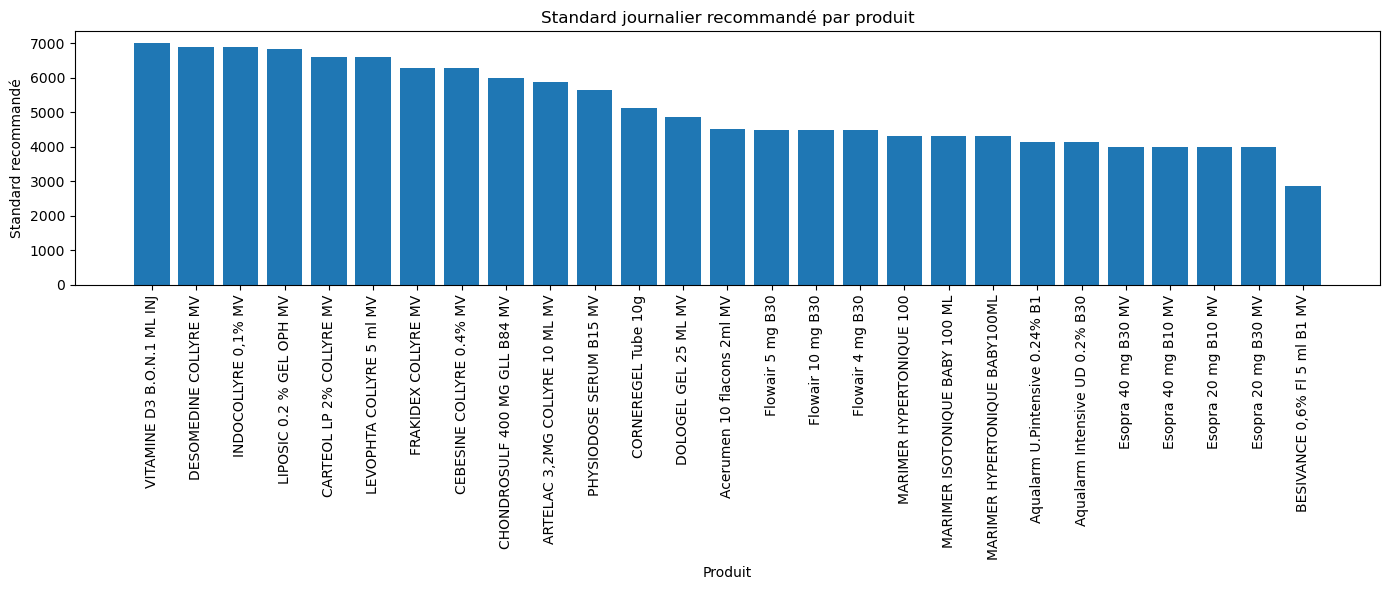

✅ Graphe 1 exporté sur le Bureau


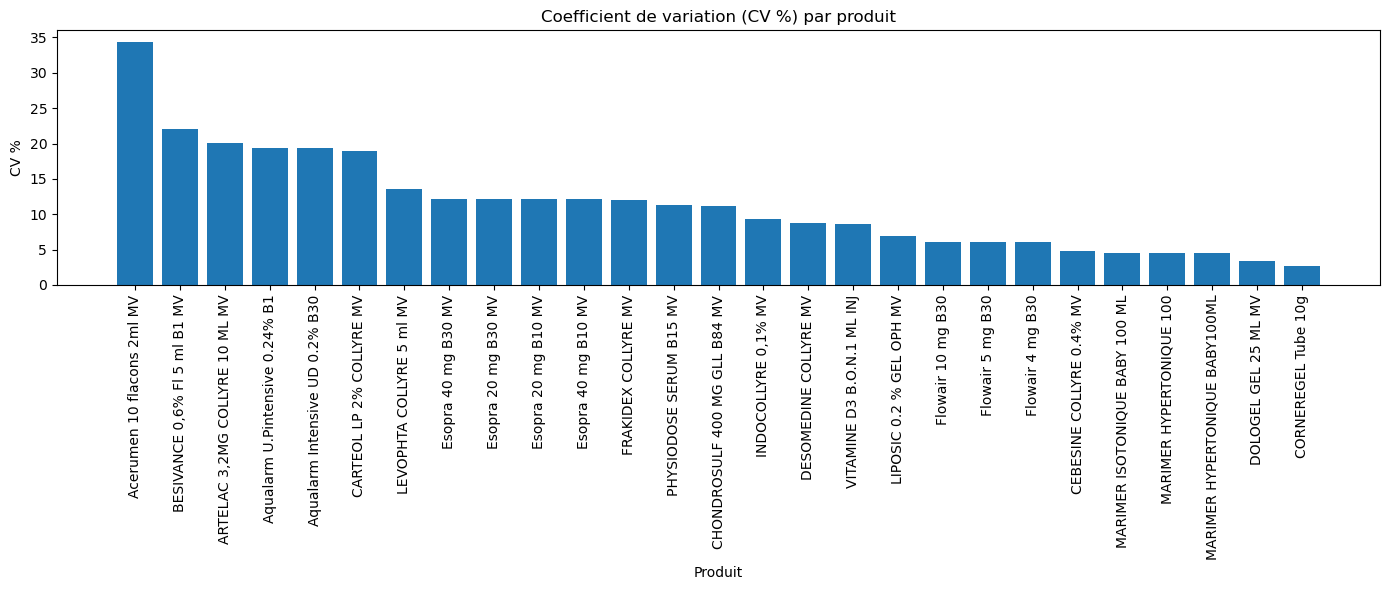

✅ Graphe 2 exporté sur le Bureau


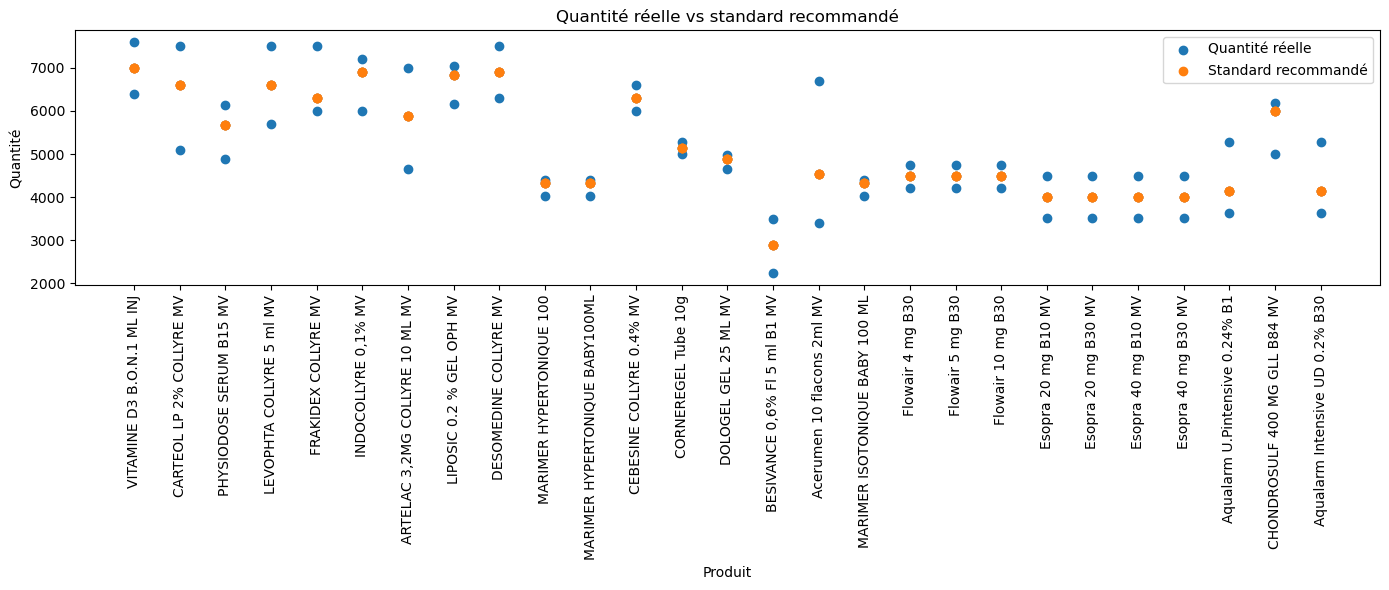

✅ Graphe 3 exporté sur le Bureau


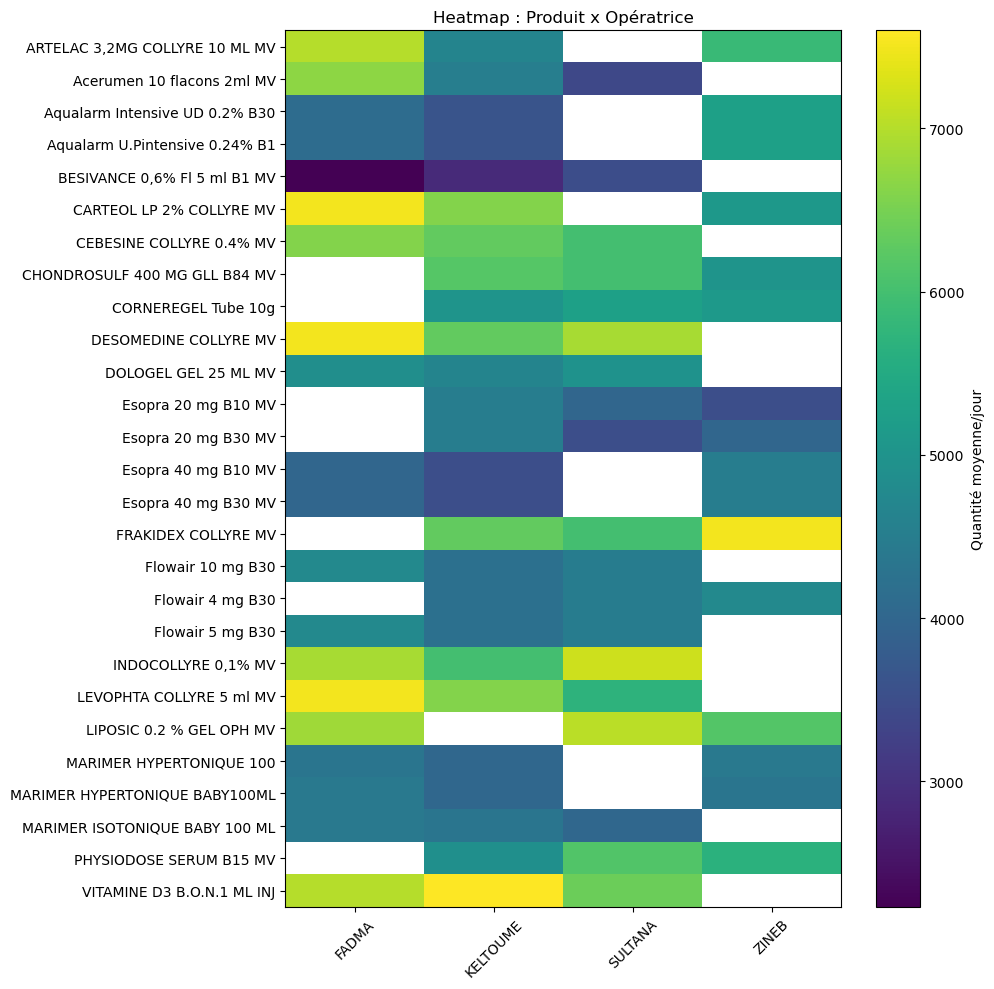

✅ Graphe 4 exporté sur le Bureau


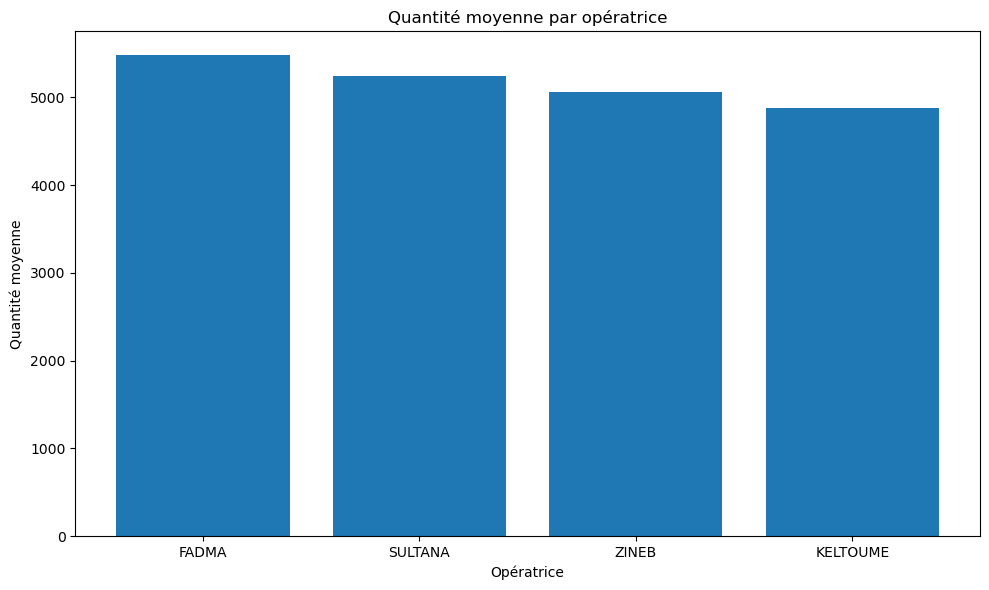

✅ Graphe 5 exporté sur le Bureau

✅ Fichier Excel exporté avec succès : C:\Users\AdMin\Desktop\Pilotage de la performance opérationnelle chez Zenith Pharma.xlsx
✅ Les graphes sont enregistrés dans : C:\Users\AdMin\Desktop\Graphes_Zenith_Pharma


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================
# 1) LECTURE DU FICHIER SOURCE
# =========================
chemin_fichier = r"C:\Users\AdMin\Desktop\EXERCICE REETEQUETAGE.xlsx"
df = pd.read_excel(chemin_fichier, sheet_name="BDD")

print("✅ Fichier chargé avec succès.")
print("Dimensions initiales :", df.shape)
print(df.head())

# =========================
# 2) NETTOYAGE DE BASE
# =========================
df.columns = df.columns.str.strip()

colonnes_obligatoires = [
    'nom opérateur',
    'ligne',
    'Code produit',
    'Produit à ré-étiqueter',
    'N° de lot',
    'Type de changement PH/ PPCou PPV',
    'Quantité/jour',
    'DATE'
]

colonnes_manquantes = [col for col in colonnes_obligatoires if col not in df.columns]
if colonnes_manquantes:
    raise ValueError(f"Colonnes manquantes : {colonnes_manquantes}")

df['Quantité/jour'] = pd.to_numeric(df['Quantité/jour'], errors='coerce')
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')

df = df.dropna(subset=['Code produit', 'Produit à ré-étiqueter', 'nom opérateur', 'Quantité/jour'])

df['nom opérateur'] = df['nom opérateur'].astype(str).str.strip().str.upper()
df['Produit à ré-étiqueter'] = df['Produit à ré-étiqueter'].astype(str).str.strip()
df['Type de changement PH/ PPCou PPV'] = df['Type de changement PH/ PPCou PPV'].astype(str).str.strip().str.upper()

print("\n✅ Base après nettoyage :")
print("Dimensions :", df.shape)
print(df.head())

# =========================
# 3) STATISTIQUES PAR PRODUIT
# =========================
stats_produit = df.groupby(['Code produit', 'Produit à ré-étiqueter']).agg(
    nb_observations=('Quantité/jour', 'count'),
    nb_operatrices=('nom opérateur', 'nunique'),
    moyenne=('Quantité/jour', 'mean'),
    mediane=('Quantité/jour', 'median'),
    minimum=('Quantité/jour', 'min'),
    maximum=('Quantité/jour', 'max'),
    ecart_type=('Quantité/jour', 'std')
).reset_index()

stats_produit['ecart_type'] = stats_produit['ecart_type'].fillna(0)

stats_produit['CV_%'] = np.where(
    stats_produit['moyenne'] != 0,
    (stats_produit['ecart_type'] / stats_produit['moyenne']) * 100,
    np.nan
)

stats_produit['Ecart_moy_med_%'] = np.where(
    stats_produit['mediane'] != 0,
    abs((stats_produit['moyenne'] - stats_produit['mediane']) / stats_produit['mediane']) * 100,
    np.nan
)

stats_produit['Amplitude'] = stats_produit['maximum'] - stats_produit['minimum']
stats_produit['Standard_recommande'] = stats_produit['mediane']

def niveau_fiabilite(cv):
    if pd.isna(cv):
        return "Non déterminé"
    elif cv < 10:
        return "Fiable"
    elif cv < 20:
        return "Acceptable"
    else:
        return "A surveiller"

stats_produit['Niveau_fiabilite'] = stats_produit['CV_%'].apply(niveau_fiabilite)

def conclusion_standard(niveau):
    if niveau == "Fiable":
        return "Standard fiable et stable"
    elif niveau == "Acceptable":
        return "Standard acceptable avec surveillance"
    elif niveau == "A surveiller":
        return "Standard à surveiller"
    else:
        return "Conclusion non déterminée"

stats_produit['Conclusion'] = stats_produit['Niveau_fiabilite'].apply(conclusion_standard)

colonnes_arrondir = [
    'moyenne', 'mediane', 'minimum', 'maximum',
    'ecart_type', 'CV_%', 'Ecart_moy_med_%',
    'Amplitude', 'Standard_recommande'
]
stats_produit[colonnes_arrondir] = stats_produit[colonnes_arrondir].round(2)

print("\n✅ Standards_fiabilite :")
print(stats_produit.head())

# =========================
# 4) AJOUT DES STANDARDS DANS LA BASE DETAIL
# =========================
df = df.merge(
    stats_produit[['Code produit', 'Produit à ré-étiqueter', 'Standard_recommande', 'Niveau_fiabilite', 'CV_%', 'Conclusion']],
    on=['Code produit', 'Produit à ré-étiqueter'],
    how='left'
)

df['Ecart_quantite'] = df['Quantité/jour'] - df['Standard_recommande']
df['Taux_atteinte_%'] = np.where(
    df['Standard_recommande'] != 0,
    (df['Quantité/jour'] / df['Standard_recommande']) * 100,
    np.nan
)

df['Ecart_quantite'] = df['Ecart_quantite'].round(2)
df['Taux_atteinte_%'] = df['Taux_atteinte_%'].round(2)

def classe_atteinte(taux):
    if pd.isna(taux):
        return "Non déterminé"
    elif taux < 90:
        return "Sous le standard"
    elif taux <= 110:
        return "Autour du standard"
    else:
        return "Au-dessus du standard"

df['Classe_atteinte'] = df['Taux_atteinte_%'].apply(classe_atteinte)

print("\n✅ Base_enrichie :")
print(df.head())

# =========================
# 5) ANALYSE PAR OPERATRICE
# =========================
analyse_operatrice = df.groupby('nom opérateur').agg(
    nb_observations=('Quantité/jour', 'count'),
    quantite_moyenne=('Quantité/jour', 'mean'),
    quantite_mediane=('Quantité/jour', 'median'),
    ecart_type=('Quantité/jour', 'std')
).reset_index()

analyse_operatrice['ecart_type'] = analyse_operatrice['ecart_type'].fillna(0)
analyse_operatrice[['quantite_moyenne', 'quantite_mediane', 'ecart_type']] = \
    analyse_operatrice[['quantite_moyenne', 'quantite_mediane', 'ecart_type']].round(2)

print("\n✅ Analyse_operatrice :")
print(analyse_operatrice)

# =========================
# 6) SYNTHESE PRODUITS
# =========================
synthese_produits = stats_produit.copy()
synthese_produits = synthese_produits.sort_values(by='CV_%', ascending=True).reset_index(drop=True)

print("\n✅ Synthese_produits :")
print(synthese_produits.head())

# =========================
# 7) PREPARER LE DOSSIER DES GRAPHES
# =========================
bureau = os.path.join(os.path.expanduser("~"), "Desktop")
dossier_graphes = os.path.join(bureau, "Graphes_Zenith_Pharma")
os.makedirs(dossier_graphes, exist_ok=True)

print(f"\n✅ Dossier des graphes créé : {dossier_graphes}")

# =========================
# 8) GRAPHE 1 : STANDARD PAR PRODUIT
# =========================
visu_standard = stats_produit.sort_values('Standard_recommande', ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(visu_standard['Produit à ré-étiqueter'], visu_standard['Standard_recommande'])
plt.xticks(rotation=90)
plt.title("Standard journalier recommandé par produit")
plt.xlabel("Produit")
plt.ylabel("Standard recommandé")
plt.tight_layout()
plt.savefig(os.path.join(dossier_graphes, "graphe_1_standard_par_produit.png"), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graphe 1 exporté sur le Bureau")

# =========================
# 9) GRAPHE 2 : CV PAR PRODUIT
# =========================
visu_cv = stats_produit.sort_values('CV_%', ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(visu_cv['Produit à ré-étiqueter'], visu_cv['CV_%'])
plt.xticks(rotation=90)
plt.title("Coefficient de variation (CV %) par produit")
plt.xlabel("Produit")
plt.ylabel("CV %")
plt.tight_layout()
plt.savefig(os.path.join(dossier_graphes, "graphe_2_cv_par_produit.png"), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graphe 2 exporté sur le Bureau")

# =========================
# 10) GRAPHE 3 : REEL VS STANDARD
# =========================
plt.figure(figsize=(14, 6))
plt.scatter(df['Produit à ré-étiqueter'], df['Quantité/jour'], label='Quantité réelle')
plt.scatter(df['Produit à ré-étiqueter'], df['Standard_recommande'], label='Standard recommandé')
plt.xticks(rotation=90)
plt.title("Quantité réelle vs standard recommandé")
plt.xlabel("Produit")
plt.ylabel("Quantité")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(dossier_graphes, "graphe_3_reel_vs_standard.png"), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graphe 3 exporté sur le Bureau")

# =========================
# 11) GRAPHE 4 : HEATMAP PRODUIT x OPERATRICE
# =========================
table_heatmap = df.pivot_table(
    index='Produit à ré-étiqueter',
    columns='nom opérateur',
    values='Quantité/jour',
    aggfunc='mean'
)

plt.figure(figsize=(10, 10))
plt.imshow(table_heatmap, aspect='auto')
plt.colorbar(label='Quantité moyenne/jour')
plt.xticks(range(len(table_heatmap.columns)), table_heatmap.columns, rotation=45)
plt.yticks(range(len(table_heatmap.index)), table_heatmap.index)
plt.title("Heatmap : Produit x Opératrice")
plt.tight_layout()
plt.savefig(os.path.join(dossier_graphes, "graphe_4_heatmap_produit_operatrice.png"), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graphe 4 exporté sur le Bureau")

# =========================
# 12) GRAPHE 5 : QUANTITE MOYENNE PAR OPERATRICE
# =========================
analyse_operatrice_triee = analyse_operatrice.sort_values('quantite_moyenne', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(analyse_operatrice_triee['nom opérateur'], analyse_operatrice_triee['quantite_moyenne'])
plt.title("Quantité moyenne par opératrice")
plt.xlabel("Opératrice")
plt.ylabel("Quantité moyenne")
plt.tight_layout()
plt.savefig(os.path.join(dossier_graphes, "graphe_5_quantite_moyenne_par_operatrice.png"), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graphe 5 exporté sur le Bureau")

# =========================
# 13) EXPORT FINAL EXCEL
# =========================
chemin_export = os.path.join(bureau, "Pilotage de la performance opérationnelle chez Zenith Pharma.xlsx")

with pd.ExcelWriter(chemin_export, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Base_enrichie', index=False)
    stats_produit.to_excel(writer, sheet_name='Standards_fiabilite', index=False)
    analyse_operatrice.to_excel(writer, sheet_name='Analyse_operatrice', index=False)
    synthese_produits.to_excel(writer, sheet_name='Synthese_produits', index=False)

print(f"\n✅ Fichier Excel exporté avec succès : {chemin_export}")
print(f"✅ Les graphes sont enregistrés dans : {dossier_graphes}")